In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

from tqdm.notebook import tqdm # прогресс бар при работе с циклами
from torch.utils.data import DataLoader

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


### 🛠️ Определение модели и переменных <a id='first'></a>

In [ ]:
class ModelPINN(nn.Module):
    def __init__(self, input=4, output=1, hidden_size=128, layers_count=4, act="tanh"):
        super().__init__()
        self.acts = {
            "tanh" : nn.Tanh(), #3
            "silu" : nn.SiLU(), #2
            "gelu" : nn.GELU(), #1
        }

        self.layers = nn.ModuleList()
        for i in range(layers_count):
            self.layers.add_module(f"layer_{i}", nn.Linear(input, hidden_size))
            self.layers.add_module(f"act_{i}", self.acts[act])

            input = hidden_size
        self.layers.add_module(f"layer_{layers_count}", nn.Linear(input, output))

    def forward(self,x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
        out = x
        return out

In [ ]:
model_PINN = ModelPINN(layers_count=12, act="gelu").to(device)

In [ ]:
SPEED = torch.tensor([100.0], device=device)
SPEED_ = torch.tensor([500.0], device=device)
COUNT_DATA = 10000
SIZE_BATCH = 10000
EPOCHS = 100000

In [ ]:
opt = torch.optim.Adam(model_PINN.parameters(), lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,
                                                          mode="min",
                                                          factor=0.1,
                                                          patience=2500,
                                                          )

In [ ]:
class EarlyStopping():
    def __init__(self, mode="min", patience=10, treshold=1e-7, threshold_mode="rel"):
        if mode not in {"min", "max"}:
            raise ValueError(f"Только параметры min и max")
        if threshold_mode not in {"rel", "abs"}:
            raise ValueError(f"Тольуо значения rel abs")
        if not isinstance(patience, int):
            raise TypeError(f"Параметр patience должен быть целым числом")
        if not isinstance (treshold, float):
            raise TypeError(f"Параметр treshold должен быть вещ числом")
        if treshold >= 1.0:
            raise ValueError(f"treshold должен быть менье 1")

        self.mode = mode
        self.patience = patience
        self.treshold = treshold
        self.threshold_mode = threshold_mode
        self.count = 0
        self.best = None

    def __call__(self, tracked_parameter):
        current = float(tracked_parameter)
        if self.best is None:
            self.best = current
            return False

        if self.changed_better(current, self.best):
            self.best = current
            self.count = 0
        else:
            self.count += 1

        if self.count >= self.patience:
            self.count = 0
            return True
        return False

    def changed_better(self, current, best):
        if self.mode == "min" and self.threshold_mode == "rel":
            return current < best - best * self.treshold

        elif self.mode == "min" and self.threshold_mode == "abs":
            return current < best - self.treshold

        elif self.mode == "max" and self.threshold_mode == "rel":
            return current > best + best * self.treshold

        else:
            return current > best + self.treshold


In [ ]:
erly_stopping = EarlyStopping(mode="min", patience=20000)

### 📊 Создание данных <a id='four'></a>

In [ ]:
#position = (torch.rand(COUNT_DATA,1) *2 -1).to(device)
#velocity = (torch.rand(COUNT_DATA,1) *2 -1).to(device)
#w = (torch.rand(COUNT_DATA, 1)).to(device)
#t = (torch.rand(COUNT_DATA,1)*2).to(device)

In [ ]:
full_data = torch.rand(COUNT_DATA, 4, device=device)
full_data[:, 1] = full_data[:, 1] * 2 - 1
full_data[:, 2] = full_data[:, 2] * 2 - 1
full_data[:, 3] = full_data[:, 3] * 5


In [ ]:
data_train_ph = DataLoader(full_data, batch_size=SIZE_BATCH,shuffle=True)

### 🔄 Цикл обучения <a id='second'></a>

In [ ]:
epoch_loop = tqdm(range(EPOCHS+1), leave=False)

treshold = 0.001
best_loss = None
t_zero = torch.zeros((SIZE_BATCH, 1), device=device, requires_grad=True)

for epoch in epoch_loop:
    mean_loss_list = []
    mean_loss_velocity = []
    mean_loss_position = []

    for batch in data_train_ph:
        t = batch[:, 0:1].requires_grad_(True)
        velocity = batch[:, 1:2].requires_grad_(True)
        position = batch[:, 2:3].requires_grad_(True)
        w = batch[:, 3:].requires_grad_(True)

        input_data = torch.cat((t, velocity, position, w), dim=1)

        opt.zero_grad()

        y = model_PINN(input_data)

        y_dot = torch.autograd.grad(y, t, torch.ones_like(y), create_graph=True)[0]
        y_dot_dot = torch.autograd.grad(y_dot, t, torch.ones_like(y_dot), create_graph=True)[0]

        loss_ph = torch.mean((y_dot_dot + w**2 * y)**2)

        input_zero = torch.cat((t_zero, velocity, position, w), dim=1).requires_grad_(True)

        y_0 = model_PINN(input_zero)
        y_dot_0 = torch.autograd.grad(y_0, t_zero, torch.ones_like(y_0), create_graph=True)[0]

        loss_pos = torch.mean((position - y_0)**2)
        loss_vel = torch.mean((velocity - y_dot_0)**2)

        total_loss = SPEED_*loss_ph + SPEED*(loss_vel + loss_pos)
        mean_loss_list.append(total_loss.item())
        mean_loss_position.append(loss_pos.item())
        mean_loss_velocity.append(loss_vel.item())

        #epoch_loop.set_description(f"Эпоха {epoch+1}; mean_loss={sum(mean_loss_list)/len(mean_loss_list)}; vel={sum(mean_loss_velocity)/len(mean_loss_velocity)}; pos={sum(mean_loss_position)/len(mean_loss_position)}; ")
        total_loss.backward()
        opt.step()

    lr_scheduler.step(sum(mean_loss_list)/len(mean_loss_list))

    if epoch % 1000 == 0:
      mean_loss = sum(mean_loss_list)/len(mean_loss_list)

      if best_loss is None:
        best_loss = mean_loss
      if mean_loss < (best_loss - best_loss *treshold):
        best_loss = mean_loss

        save_dict = {"state_dict" : model_PINN.state_dict(),
                     "state_shedduler" : lr_scheduler.state_dict(),
                     "epoch_step": epoch,
                     "best_loss":best_loss}

        torch.save(save_dict, "drive/MyDrive/save/model_pinn_four_param_hard.pth")
        print(f"На эпоху {epoch+1} сохранена модель со значение mean_loss {best_loss}")

    if epoch % 1000 == 0:
      lr = lr_scheduler.get_last_lr()
      print(f"Эпоха {epoch+1}; mean_loss={mean_loss:.10f}; vel={sum(mean_loss_velocity)/len(mean_loss_velocity):.10f}; pos={sum(mean_loss_position)/len(mean_loss_position):.10f}; lr={lr[0]:.10f}\n")

    if erly_stopping(mean_loss):
      print(f"\033[31mОбучение остаговлено на {epoch+1} эпохе \033[0m")
      break


  0%|          | 0/100001 [00:00<?, ?it/s]

Эпоха 1; mean_loss=387.1018676758; vel=0.3366414905; pos=0.3408621848; lr=0.0010000000

На эпоху 1001 сохранена модель со значение mean_loss 4.648871421813965
Эпоха 1001; mean_loss=4.6488714218; vel=0.0031993121; pos=0.0355273746; lr=0.0010000000

На эпоху 2001 сохранена модель со значение mean_loss 0.9555450081825256
Эпоха 2001; mean_loss=0.9555450082; vel=0.0005020408; pos=0.0070052985; lr=0.0010000000

Эпоха 3001; mean_loss=1.4472370148; vel=0.0008513035; pos=0.0078189112; lr=0.0010000000

Эпоха 4001; mean_loss=1.2627267838; vel=0.0007011061; pos=0.0026144395; lr=0.0010000000

На эпоху 5001 сохранена модель со значение mean_loss 0.33496811985969543
Эпоха 5001; mean_loss=0.3349681199; vel=0.0002111634; pos=0.0019340644; lr=0.0010000000

Эпоха 6001; mean_loss=0.5415318012; vel=0.0002177012; pos=0.0025671560; lr=0.0010000000

Эпоха 7001; mean_loss=1.4586056471; vel=0.0005011272; pos=0.0022684338; lr=0.0010000000

Эпоха 8001; mean_loss=0.5541455746; vel=0.0001461800; pos=0.0009710154; l

In [ ]:
state_dict = torch.load("drive/MyDrive/save/model_pinn_four_param_hard.pth",map_location=device)
model_PINN.load_state_dict(state_dict["state_dict"])

<All keys matched successfully>

### 🧪 Тестирование <a id='third'></a>

#### 🔵 Тест: Косинус ($w=5$) <a id="third_one"></a>

In [ ]:
t_test = torch.linspace(0,1,1000).reshape(1000,1).to(device)
w_test = torch.full_like(t_test,5).to(device)
velocity_test = torch.full_like(t_test, 0).to(device)
position_test = torch.full_like(t_test, 1).to(device)
input_test = torch.cat((t_test, velocity_test, position_test, w_test), dim=1).requires_grad_(True).to(device)

In [ ]:
y = model_PINN(input_test)
y_norm = y.detach().cpu().numpy()
t_norm = t_test.detach().cpu().numpy()

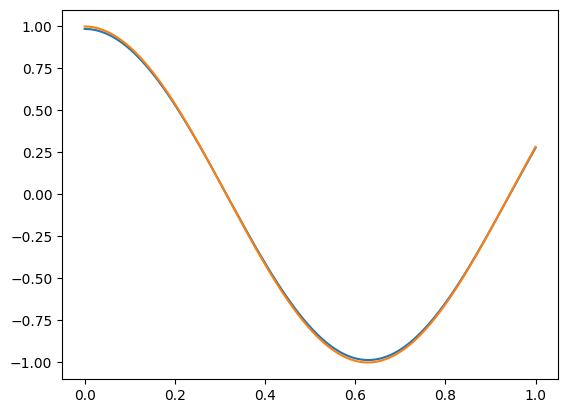

In [ ]:
plt.plot(t_norm, y_norm)
plt.plot(t_norm, np.cos(5*t_norm))


#### 🟢 Тест: Синус ($w=5$) <a id="third_two"></a>

In [ ]:
t_test = torch.linspace(0,1,1000).reshape(1000,1).to(device)
w_test = torch.full_like(t_test,5).to(device)
velocity_test = torch.full_like(t_test, 5).to(device)
position_test = torch.full_like(t_test, 0).to(device)
input_test = torch.cat((t_test, velocity_test, position_test, w_test), dim=1).requires_grad_(True).to(device)

In [ ]:
y = model_PINN(input_test)
y_norm = y.detach().cpu().numpy()
t_norm = t_test.detach().cpu().numpy()

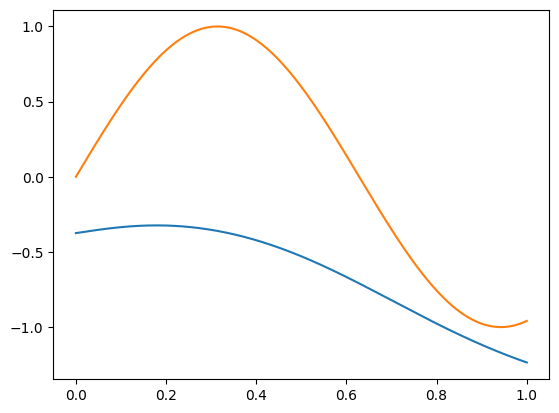

In [ ]:
plt.plot(t_norm, y_norm)
plt.plot(t_norm, np.sin(5 * t_norm))

### 💾 Сохранение на Google Drive <a id="four"></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
